# Project Definition: Telecom Customer Churn Analysis

## 1. Business Case
In the highly competitive telecommunications industry, retaining existing customers is significantly more cost-effective than acquiring new ones. Customer churn (attrition) directly impacts corporate revenue and signals potential underlying issues in service quality, pricing structures, or customer support satisfaction. 

This project investigates a real-world telecom dataset containing customer usage profiles, plan subscriptions, and customer service interaction history. By uncovering the specific pain points and behavioral triggers that lead to customer defection, the business can shift from a reactive state to a proactive retention strategy—minimizing financial losses and safeguarding Customer Lifetime Value (LTV).

## 2. Project Objectives
The primary analytical and strategic goals of this Exploratory Data Analysis (EDA) are to:
* **Establish the Baseline Attrition Rate:** Quantify the exact percentage of the subscriber base currently leaving the provider.
* **Identify Operational Breakdowns:** Isolate actionable thresholds in customer support interactions (e.g., call frequencies) where customer tolerance drops significantly.
* **Evaluate Product & Pricing Friction:** Investigate financial anomalies within high-tier offerings, specifically analyzing daytime usage charges and International Plan tiers to detect "bill shock" triggers.
* **Assess Regional Uniformity:** Determine whether churn is a localized infrastructural issue (network quality in certain areas) or a centralized, systemic problem across the entire customer experience.
* **Deliver Data-Driven Strategies:** Translate statistical findings into high-impact, actionable business recommendations for executive leadership to curb revenue leakage and maximize customer retention.

In [49]:
!pip install pandas numpy seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
!pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
df=pd.read_excel('Telecom_Churn_Data.xlsx')

In [53]:
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [54]:
#1. check dat dimensions(Rows & Columns)
print ("Current Data Dimensions:")
print (f"Number Of  rows (Customers):{df.shape[0]}")
print (f"Number of coloumns(Feature):{df.shape[1]}")

Current Data Dimensions:
Number Of  rows (Customers):3333
Number of coloumns(Feature):21


In [55]:
#2.Inspect coulmn name,data types,and  missing values
print("information about data coulmns and type:")
df.info()


information about data coulmns and type:
<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   str    
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   str    
 4   international plan      3333 non-null   str    
 5   voice mail plan         3333 non-null   str    
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total nigh

In [56]:
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [57]:
df.describe(include="O")

C:\Users\User\AppData\Local\Temp\ipykernel_11612\504318277.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="O")


,state,phone number,international plan,voice mail plan
count,3333,3333,3333,3333
unique,51,3333,2,2
top,WV,382-4657,no,no
freq,106,1,3010,2411


In [58]:
df['churn'].unique()

array([False,  True])

In [59]:

# Calculate how many customers are left vs stay
print("Customer count:")
print(df['churn'].value_counts())
print("\n" +"-"*30 + "\n")      

Customer count:
churn
False    2850
True      483
Name: count, dtype: int64

------------------------------



In [60]:
# calcolate the Overall Churn rate Percentage

round(len(df[df['churn']==True])/len(df)*100,2)

14.49

In [61]:
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='str')

In [62]:
# Calculate the average number of customer service call for churnend vs retained customers
avg_service_call=df.groupby('churn')['customer service calls'].mean()
print("Average Service Call :")
print(round(avg_service_call,2))

Average Service Call :
churn
False    1.45
True     2.23
Name: customer service calls, dtype: float64


In [63]:
pd.crosstab(df['customer service calls'],df['churn'],normalize='index')*100

churn,False,True
customer service calls,,
0,86.800574,13.199426
1,89.669771,10.330229
2,88.537549,11.462451
3,89.743590,10.256410
4,54.216867,45.783133
5,39.393939,60.606061
6,36.363636,63.636364
7,44.444444,55.555556
8,50.000000,50.000000


In [64]:
# Check the churn rate percentage based on having an international plan
intl_churn_table = pd.crosstab(df['international plan'], df['churn'], normalize='index') * 100

print(" Churn Percentage by International Plan:")
print(round(intl_churn_table, 2))

 Churn Percentage by International Plan:
churn               False  True 
international plan              
no                  88.50  11.50
yes                 57.59  42.41


In [65]:
# Filter the data for customers who have an international plan
intl_customers = df[df['international plan'] == 'yes']

# Calculate the average international minutes and charges grouped by churn
intl_financials = intl_customers.groupby('churn')[['total intl minutes','total intl calls', 'total intl charge']].mean()

print(" International Calls Usage and Charges Analysis:")
print(round(intl_financials, 2))

 International Calls Usage and Charges Analysis:
       total intl minutes  total intl calls  total intl charge
churn                                                         
False                9.78              5.10               2.64
True                11.78              3.94               3.18


In [66]:
# Calculate average daytime minutes and charges for churned vs retained customers
day_usage_analysis = df.groupby('churn')[['total day minutes','total day calls', 'total day charge']].mean()

print(" Daytime Calls Usage and Charges Analysis:")
print(round(day_usage_analysis, 2))


 Daytime Calls Usage and Charges Analysis:
       total day minutes  total day calls  total day charge
churn                                                      
False             175.18           100.28             29.78
True              206.91           101.34             35.18


In [67]:
# Calculate average evening time minutes and charges for churned vs retained customers
eve_usage_analysis = df.groupby('churn')[['total eve minutes','total eve calls', 'total eve charge']].mean()

print("Evening Calls Usage and Charges Analysis:")
print(round(eve_usage_analysis, 2))

Evening Calls Usage and Charges Analysis:
       total eve minutes  total eve calls  total eve charge
churn                                                      
False             199.04           100.04             16.92
True              212.41           100.56             18.05


In [68]:
night_usage_analysis=df.groupby('churn')[['total night minutes','total night calls', 'total night charge']].mean()
print("night Calls Usage and Charges Analysis:")
print(round(night_usage_analysis, 2))


night Calls Usage and Charges Analysis:
       total night minutes  total night calls  total night charge
churn                                                            
False               200.13             100.06                9.01
True                205.23             100.40                9.24


In [69]:
pd.crosstab(df['area code'],df['churn'],normalize='index')*100

churn,False,True
area code,,
408,85.441527,14.558473
415,85.740181,14.259819
510,85.119048,14.880952


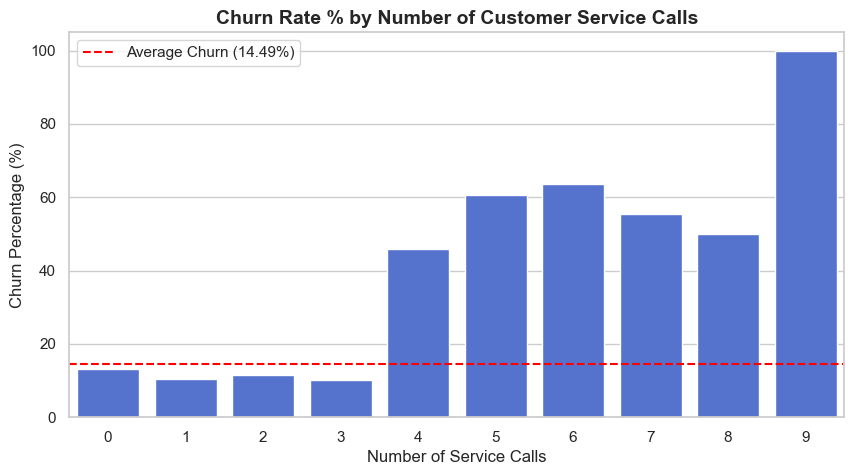

In [70]:


# 1. Calculate the churn percentage (exactly like your table)
churn_matrix = pd.crosstab(df['customer service calls'], df['churn'], normalize='index') * 100
churn_rate_line = churn_matrix[True]

# 2. Plot a simple bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=churn_rate_line.index, y=churn_rate_line.values, color='royalblue')

# 3. Add clean labels and a title
plt.title('Churn Rate % by Number of Customer Service Calls', fontsize=14, fontweight='bold')
plt.xlabel('Number of Service Calls')
plt.ylabel('Churn Percentage (%)')

# 4. Draw a clear baseline showing your overall churn rate (14.49%)
plt.axhline(y=14.49, color='red', linestyle='--', label='Average Churn (14.49%)')
plt.legend()

plt.show()

# Executive Summary & Strategic Insights

## Key Findings

* **Baseline Attrition:** The company’s overall customer churn rate stands at **14.49%** (483 out of 3,333 subscribers have defected).
* **The 4th Call Crisis:** Customer service friction is a critical churn trigger. While retained users average 1.45 calls, the churn rate aggressively spikes to **45.78% on exactly the 4th call**, exceeding 60% on subsequent attempts.
* **The International Plan Paradox:** Subscribers with an international plan exhibit an alarming **42.41% churn rate** (vs. 11.50% for non-subscribers). These users make fewer calls but stay on the line longer, triggering heavy per-minute price compounding and immediate bill shock.
* **Loss of High-Value Assets:** Churners are the company’s most profitable, high-consuming segment, averaging **206.91 daytime minutes** ($35.18 bill) compared to retained users at 175.18 minutes ($29.78 bill).
* **Systemic Pricing Issue:** Churn rates remain perfectly uniform across all area codes (**~14.5% across 408, 415, and 510**), proving that the issue is not caused by localized network quality, but rather by centralized pricing and customer care execution.

---

## Strategic Recommendations

* **Deploy a Call-3 "Circuit Breaker":** Automate a proactive trigger in the CRM system to flag any subscriber reaching their 3rd customer service call. Route these accounts immediately to a specialized "VIP Resolution Team" to resolve their issues before the catastrophic 4th call.
* **Restructure International Pricing:** Replace the strict, compounding per-minute pricing structure on international plans with fixed bucket-hours (e.g., introducing a flat-rate plan with 300 included international minutes) to eliminate damaging bill shock.
* **Introduce a High-Volume Daytime Tier:** Proactively offer high-volume daytime callers (those exceeding 180 minutes) an automatic upgrade to an unlimited flat-rate daytime package. Subsidizing a slight drop in per-minute margins is significantly cheaper than losing their entire Lifetime Value (LTV).
* **Shift CS Metrics to Quality Over Speed:** Transition customer service Key Performance Indicators (KPIs) away from Average Handling Time (AHT) and prioritize First Contact Resolution (FCR) to ensure agents definitively solve problems rather than rushing users off the phone.